In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve
import shap

X_train, X_test, y_train, y_test = pickle.load(open('../artifacts/preprocessed_data.pkl', 'rb'))
feature_names = pickle.load(open('../artifacts/feature_names.pkl', 'rb'))

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1972, 52)
Test shape: (294, 52)


c:\Users\Deepshikha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Training complete")

Training complete


=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

No Attrition       0.87      0.94      0.90       247
   Attrition       0.46      0.28      0.35        47

    accuracy                           0.83       294
   macro avg       0.67      0.61      0.63       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC: 0.7992


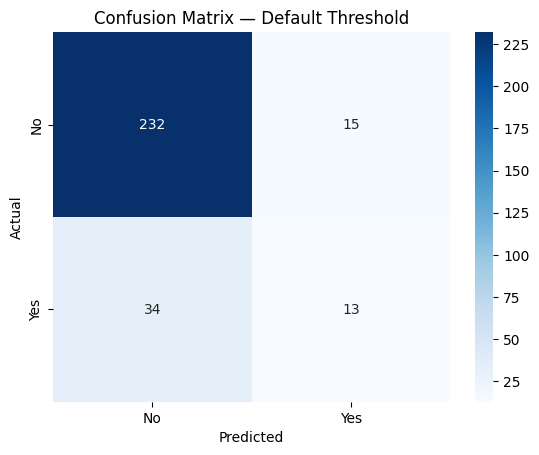

In [3]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=== Default Threshold (0.5) ===")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix — Default Threshold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Best threshold: 0.3036
Best F1 at this threshold: 0.5373


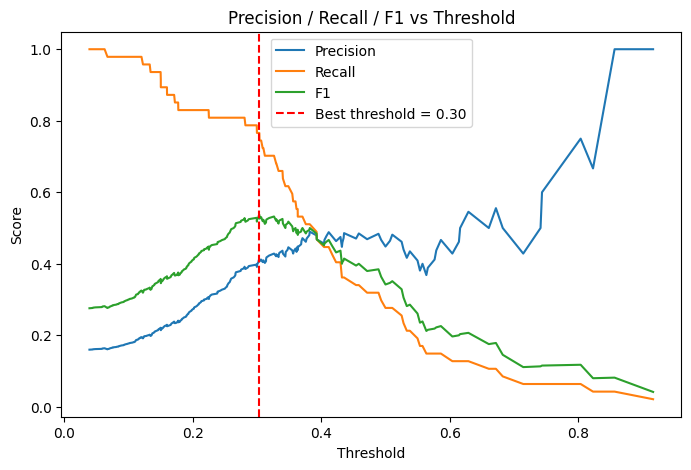

In [4]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]

print(f"Best threshold: {best_threshold_rf:.4f}")
print(f"Best F1 at this threshold: {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold_rf, color='red', linestyle='--', label=f'Best threshold = {best_threshold_rf:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.show()

=== Optimal Threshold (0.3036) ===
              precision    recall  f1-score   support

No Attrition       0.95      0.79      0.86       247
   Attrition       0.41      0.77      0.54        47

    accuracy                           0.79       294
   macro avg       0.68      0.78      0.70       294
weighted avg       0.86      0.79      0.81       294

ROC-AUC: 0.7992


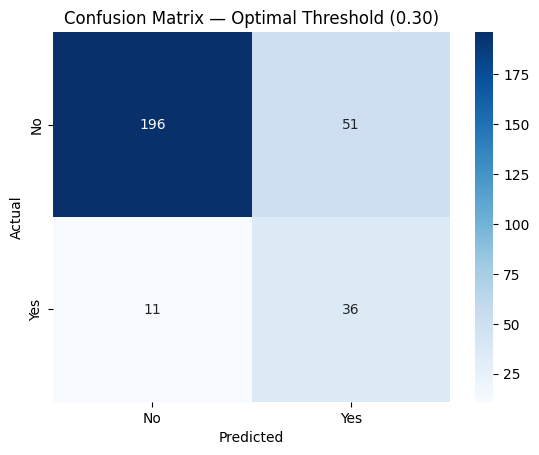

In [5]:
y_pred_optimal = (y_proba >= best_threshold_rf).astype(int)

print(f"=== Optimal Threshold ({best_threshold_rf:.4f}) ===")
print(classification_report(y_test, y_pred_optimal, target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm2 = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix — Optimal Threshold ({best_threshold_rf:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

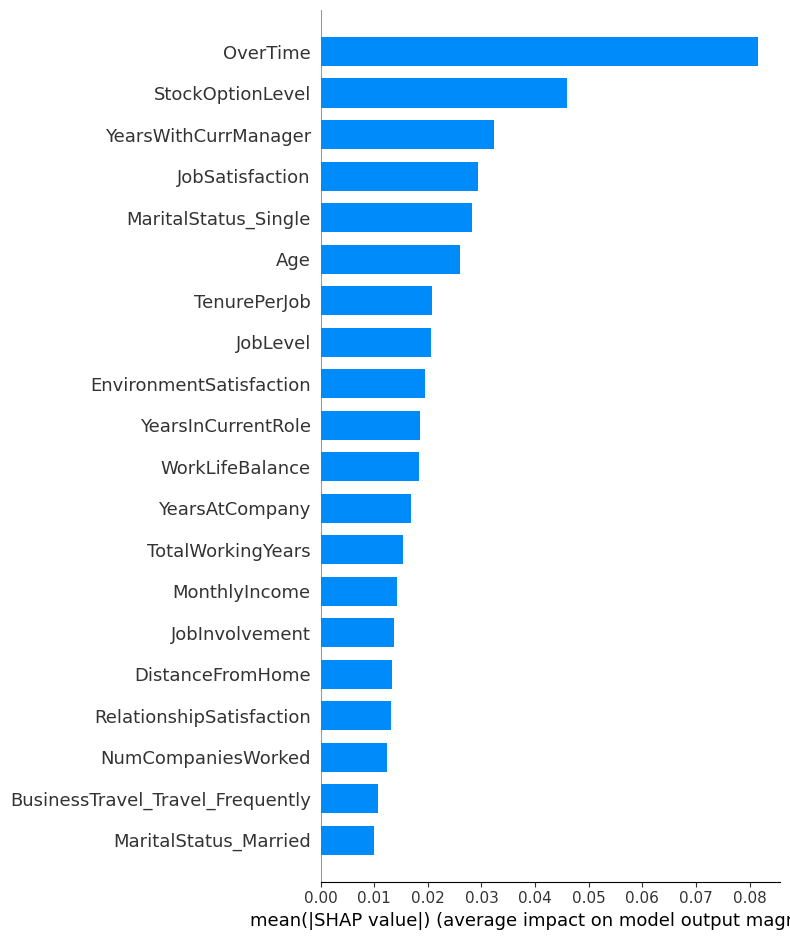

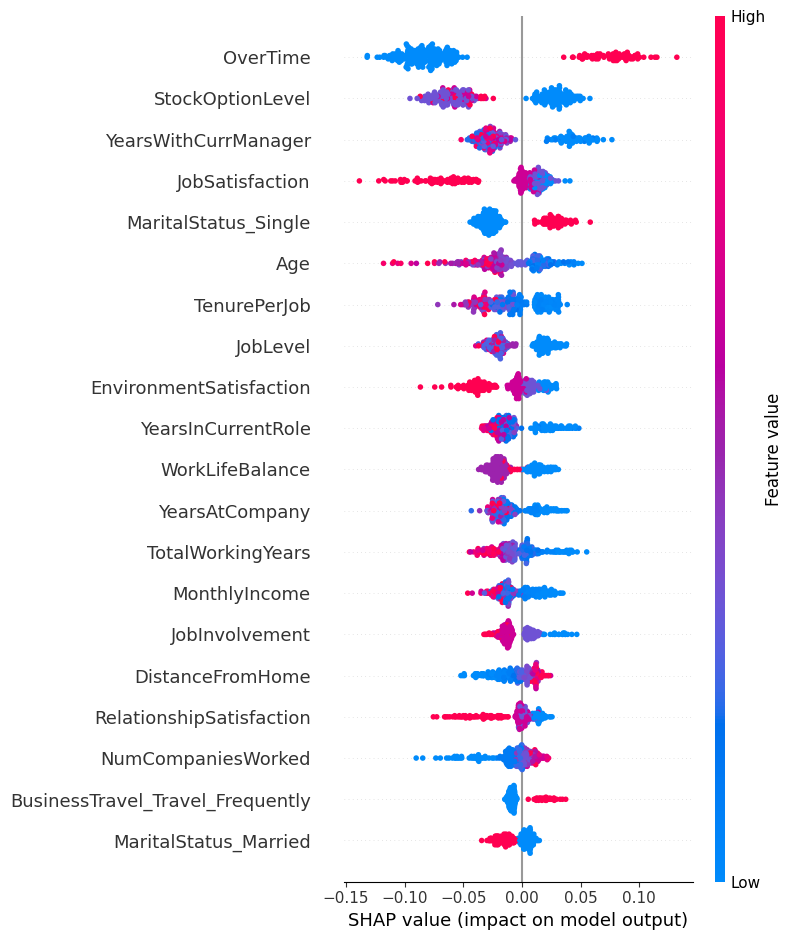

In [6]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, 
                  feature_names=feature_names, 
                  plot_type='bar', show=True)

plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, 
                  feature_names=feature_names, show=True)

In [7]:
pickle.dump(rf, open('../artifacts/rf_model.pkl', 'wb'))
pickle.dump(best_threshold_rf, open('../artifacts/rf_threshold.pkl', 'wb'))

print("Saved to artifacts/")

Saved to artifacts/
